
<h1 align="center"><font size="6"><b>Project: Analzying House Sales in King County, USA </b></font></h1>


### Table of Contents
<div class="alert alert-block alert-info" style="margin-top: 20px">
    <ul>
    <li><a href="#About-the-Dataset">Dataset</a></li>
    <li><a href="#Module-1:-Importing-Data-Sets">Importing Data </a></li>
    <li><a href="#Module-2:-Data-Wrangling">Data Wrangling</a> </li>
    <li><a href="#Module-3:-Exploratory-Data-Analysis">Exploratory Data Analysis</a></li>
    <li><a href="#Module-4:-Model-Development">Model Development</a></li>
    <li><a href="#Module-5:-Model-Evaluation-and-Refinement">Model Evaluation and Refinement</a></li>
</a></li>
</div>

<hr>


In this notebook, I am analyzing a Real Estate Investment Trust. The Trust would like to start investing in Residential real estate. I have determined the market price of a house given a set of features. I analyzed and predicted housing prices using attributes or features such as square footage, number of bedrooms, number of floors, and so on.


### Dataset

This dataset contains house sale prices for King County, which includes Seattle. It includes homes sold between May 2014 and May 2015. It was taken from [here](https://www.kaggle.com/harlfoxem/housesalesprediction?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-wwwcourseraorg-SkillsNetworkCoursesIBMDeveloperSkillsNetworkDA0101ENSkillsNetwork20235326-2022-01-01).


| Variable      | Description                                                                                                 |
| ------------- | ----------------------------------------------------------------------------------------------------------- |
| id            | A notation for a house                                                                                      |
| date          | Date house was sold                                                                                         |
| price         | Price is prediction target                                                                                  |
| bedrooms      | Number of bedrooms                                                                                          |
| bathrooms     | Number of bathrooms                                                                                         |
| sqft_living   | Square footage of the home                                                                                  |
| sqft_lot      | Square footage of the lot                                                                                   |
| floors        | Total floors (levels) in house                                                                              |
| waterfront    | House which has a view to a waterfront                                                                      |
| view          | Has been viewed                                                                                             |
| condition     | How good the condition is overall                                                                           |
| grade         | overall grade given to the housing unit, based on King County grading system                                |
| sqft_above    | Square footage of house apart from basement                                                                 |
| sqft_basement | Square footage of the basement                                                                              |
| yr_built      | Built Year                                                                                                  |
| yr_renovated  | Year when house was renovated                                                                               |
| zipcode       | Zip code                                                                                                    |
| lat           | Latitude coordinate                                                                                         |
| long          | Longitude coordinate                                                                                        |
| sqft_living15 | Living room area in 2015( implies some renovations)  |
| sqft_lot15    | LotSize area in 2015 (implies some renovations)                                                            |


#### Import libraries


In [45]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.model_selection import GridSearchCV;

---

### Importing Dataset


In [46]:
filepath='https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-SkillsNetwork/labs/FinalModule_Coursera/data/kc_house_data_NaN.csv'
df = pd.read_csv(filepath)
df.head()

,Unnamed: 0,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,0,7129300520,20141013T000000,221900.0,3.0,1.00,1180,5650,1.0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,1,6414100192,20141209T000000,538000.0,3.0,2.25,2570,7242,2.0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,2,5631500400,20150225T000000,180000.0,2.0,1.00,770,10000,1.0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,3,2487200875,20141209T000000,604000.0,4.0,3.00,1960,5000,1.0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,4,1954400510,20150218T000000,510000.0,3.0,2.00,1680,8080,1.0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


Displaying the data types of each column using the function `dtypes`.


In [47]:
df.dtypes

Unnamed: 0         int64
id                 int64
date              object
price            float64
bedrooms         float64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object

---
<div class="alert alert-block alert-warning">

### Data Wrangling
</div>

Droping the columns <code>"id"</code>  and <code>"Unnamed: 0"</code> from axis 1 using the method <code>drop()</code>, then using the method <code>describe()</code> to obtain a statistical summary of the data.


In [48]:
df.drop(["id", "Unnamed: 0"], axis= 1, inplace= True)
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,21600.000000,21603.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,5.400881e+05,3.372870,2.115736,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,3.671272e+05,0.926657,0.768996,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,7.500000e+04,1.000000,0.500000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [49]:
print("number of missing values for the column bedrooms :", df['bedrooms'].isnull().sum())
print("number of missing values for the column bathrooms :", df['bathrooms'].isnull().sum())

number of missing values for the column bedrooms : 13
number of missing values for the column bathrooms : 10


Replacing the missing values of the column <code>bedrooms</code> and `bathrooms` with the mean


In [50]:
mean=df['bedrooms'].mean()
df['bedrooms'].replace(np.nan,mean, inplace=True)
mean=df['bathrooms'].mean()
df['bathrooms'].replace(np.nan,mean, inplace=True)

print("number of missing values for the column bedrooms :", df['bedrooms'].isnull().sum())
print("number of missing values for the column bathrooms :", df['bathrooms'].isnull().sum())

number of missing values for the column bedrooms : 0
number of missing values for the column bathrooms : 0


---
<div class="alert alert-block alert-warning">

### Exploratory Data Analysis
</div>

Using the method <code>value_counts</code> to count the number of houses with unique floor values


In [51]:
df["floors"].value_counts().to_frame()

,count
floors,
1.0,10680
2.0,8241
1.5,1910
3.0,613
2.5,161
3.5,8


Using the function <code>boxplot</code> in the seaborn library  to  determine whether houses with a waterfront view or without a waterfront view have more price outliers.

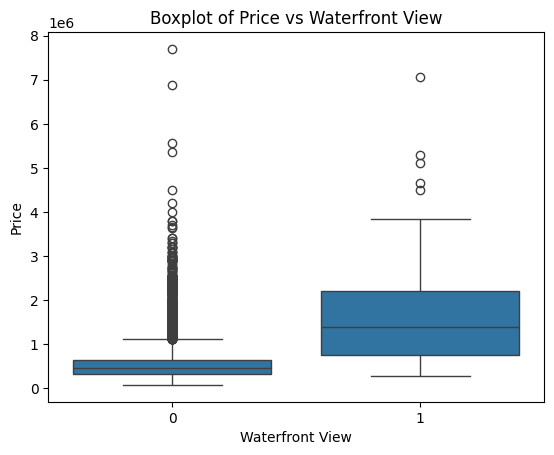

In [52]:
sns.boxplot(x="waterfront", y="price", data=df)
plt.xlabel("Waterfront View")
plt.ylabel("Price")
plt.title("Boxplot of Price vs Waterfront View")
plt.show();



Using the function <code>regplot</code>  in the seaborn library  to  determine if the feature <code>sqft_above</code> is negatively or positively correlated with price.


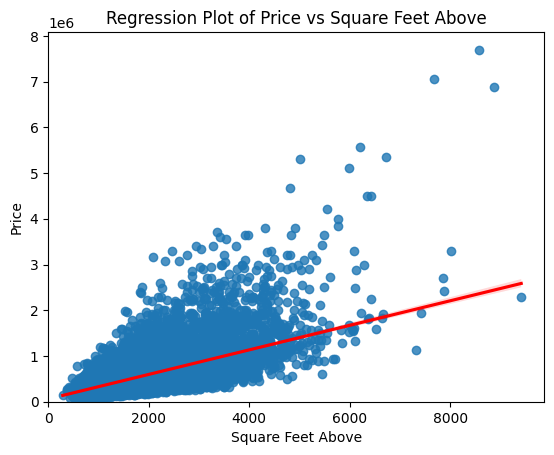

In [53]:
sns.regplot(x="sqft_above", y="price", data=df, line_kws={"color": "red"} )
plt.ylim(0,)
plt.xlim(0,)
plt.xlabel("Square Feet Above")
plt.ylabel("Price")
plt.title("Regression Plot of Price vs Square Feet Above")
plt.show();

In [54]:
df.select_dtypes(include=[np.number]).corr()['price'].sort_values(ascending=False).to_frame().round(3)

,price
price,1.000
sqft_living,0.702
grade,0.667
sqft_above,0.606
sqft_living15,0.585
bathrooms,0.526
view,0.397
sqft_basement,0.324
bedrooms,0.309
lat,0.307


---
<div class="alert alert-block alert-warning">

### Model Development
</div>


Fiting a linear regression model to predict the <code>'price'</code> using the feature <code>'sqft_living'</code> then calculating the R^2.

In [55]:
X = df[['sqft_living']]
Y = df['price']
lm = LinearRegression()
lm.fit(X,Y)
lm.score(X, Y)

0.4928532179037931

In [56]:
#Enter Your Code, Execute and take the Screenshot
x_data= df[['grade']]
y_data= df["price"]
lr= LinearRegression()
lr.fit(x_data, y_data)
lr.score(x_data, y_data)

0.44546848610928713

Fiting a linear regression model to predict the <code>'price'</code> using the list of features:


In [57]:
features =["floors", "waterfront","lat" ,"bedrooms" ,"sqft_basement" ,"view" ,"bathrooms","sqft_living15","sqft_above","grade","sqft_living"]    

Then calculating the R^2.


In [58]:
Z= df[features]
Y = df['price']
lr.fit(Z, Y)
lr.score(Z, Y)

0.6576951666037499

In [59]:
Input=[('scale',StandardScaler()),('polynomial', PolynomialFeatures(include_bias=False)),('model',LinearRegression())]


Creating a pipeline object to predict the `price`, fiting the object using the features in the list <code>features</code>, and calculating the R^2.


In [60]:
Z= df[features].astype(float)
Y = df['price']
pipe=Pipeline(Input)
pipe.fit(Z, Y)
pipe.score(Z, Y)

0.7513408515988733

---
<div class="alert alert-block alert-warning">

### Model Evaluation and Refinement
</div>


Spliting the data into training and testing sets:


In [61]:
features =["floors", "waterfront","lat" ,"bedrooms" ,"sqft_basement" ,"view" ,"bathrooms","sqft_living15","sqft_above","grade","sqft_living"]    
X = df[features]
Y = df['price']

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.15, random_state=1)


print("number of test samples:", x_test.shape[0])
print("number of training samples:",x_train.shape[0])

number of test samples: 3242
number of training samples: 18371


Creating and fiting a Ridge regression object using the training data.


In [62]:
from sklearn.linear_model import Ridge

In [63]:
RidgeModel= Ridge(alpha=0.1)
RidgeModel.fit(x_train, y_train)
round(RidgeModel.score(x_train, y_train), 3)

0.659

Creating a second order polynomial transform on both the training data and testing data.


In [64]:
pr= PolynomialFeatures(degree=2)
RidgeModel= Ridge(alpha= 0.1)
x_train_pr= pr.fit_transform(x_train)
x_test_pr= pr.fit_transform(x_test)
RidgeModel.fit(x_train_pr, y_train)
RidgeModel.score(x_train_pr, y_train)

0.7418167438711281

### Conclusion:

- The Ridge regression model with a polynomial transformation of degree 2 has been successfully fitted to the training data.
- 0.742 value of R^2 indicates a good fit of the model to the training data, suggesting that the model explains approximately 74.2% of the variance in the house prices.

---


<div class="alert alert-block alert-info">

### Author:

- [Parshv Patel](https://www.linkedin.com/in/parshv-patel-65a90326b/)
</div>